# CCS3440_AI-Final-Assignment_Group-02

# Option C: Disease Risk Classification - SmartCare Hospital

# Task 02 – Dataset Understanding

## Mount Drive & Load Data

In [69]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# change this path to wherever you put your files in Drive
folder = '/content/drive/MyDrive/SmartCare/'

df = pd.read_csv(folder + 'smartcare_ai_dataset_1000.csv')
data_dict = pd.read_csv(folder + 'smartcare_ai_dataset_data_dictionary.csv')

print(df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(1000, 33)


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,0,Completed,0,NaN,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,Paid,Insurance,0,0,High
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,1,Completed,0,NaN,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,1,No-Show,0,NaN,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium
3,4,P10004,44,Female,AB-,Cardiology,Asthma,2025-10-16,16,1,0,Completed,0,NaN,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,Paid,Online,0,0,Medium
4,5,P10005,51,Female,O+,Neurology,Hypertension,2025-12-18,12,4,0,Scheduled,0,NaN,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium


## 2.1 Dataset Overview

In [70]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   record_id                     1000 non-null   int64  
 1   patient_id                    1000 non-null   object 
 2   age                           1000 non-null   int64  
 3   gender                        1000 non-null   object 
 4   blood_group                   1000 non-null   object 
 5   department                    1000 non-null   object 
 6   diagnosis                     1000 non-null   object 
 7   appointment_date              1000 non-null   object 
 8   waiting_days                  1000 non-null   int64  
 9   previous_appointments         1000 non-null   int64  
 10  missed_previous_appointments  1000 non-null   int64  
 11  appointment_status            1000 non-null   object 
 12  admitted                      1000 non-null   int64  
 13  room

## 2.2 Attribute Description

In [71]:
# Data dictionary (attribute meanings)
data_dict

,Column,Description
0,record_id,Unique row identifier
1,patient_id,Synthetic patient identifier
2,age,Patient age in years
3,gender,Patient gender
4,blood_group,Patient blood group
5,department,Hospital department
6,diagnosis,Primary diagnosis category
7,appointment_date,Appointment date
8,waiting_days,Number of days between booking and appointment
9,previous_appointments,Number of previous appointments


## 2.3  Identify target variables.

In [72]:
# Target variable for Option C
df['disease_risk_level'].value_counts()

,count
disease_risk_level,
Medium,469
High,400
Low,131


In [73]:
# Missing values check
df.isnull().sum()[df.isnull().sum() > 0]

,0
room_type,906


In [74]:
# Check missing room_type by admitted status
pd.crosstab(df['admitted'], df['room_type'].isnull(), rownames=['admitted'], colnames=['room_type_is_null'])


room_type_is_null,False,True
admitted,,
0,0,670
1,94,236


In [75]:
# Check for duplicate rows
print('Fully duplicated rows:', df.duplicated().sum())
print('Duplicate patient_id + appointment_date combos:',
      df.duplicated(subset=['patient_id','appointment_date']).sum())

Fully duplicated rows: 0
Duplicate patient_id + appointment_date combos: 0


In [76]:
# Check data quality
quality_report = pd.DataFrame({
    'dtype': df.dtypes,
    'n_missing': df.isnull().sum(),
    'pct_missing': (df.isnull().sum() / len(df) * 100).round(2),
    'n_unique': df.nunique()
}).sort_values('pct_missing', ascending=False)
quality_report

,dtype,n_missing,pct_missing,n_unique
room_type,object,906,90.6,3
record_id,int64,0,0.0,1000
patient_id,object,0,0.0,1000
gender,object,0,0.0,2
age,int64,0,0.0,88
department,object,0,0.0,7
diagnosis,object,0,0.0,10
appointment_date,object,0,0.0,339
blood_group,object,0,0.0,8
waiting_days,int64,0,0.0,45


# Task 03 – Data Preprocessing and Feature Engineering

## 3.1 Missing value handling

In [77]:
# Missing Values Handling
df.isnull().sum()[df.isnull().sum() > 0]

pd.crosstab(df['admitted'], df['room_type'].isnull())

df_clean = df.copy()

# admitted=0 -> genuinely "no room", meaningful category
df_clean.loc[df_clean['admitted'] == 0, 'room_type'] = \
    df_clean.loc[df_clean['admitted'] == 0, 'room_type'].fillna('Not Admitted')

# admitted=1 but still missing -> real data gap, fill with most common room type
mode_room = df_clean.loc[df_clean['admitted'] == 1, 'room_type'].mode()[0]
df_clean.loc[df_clean['admitted'] == 1, 'room_type'] = \
    df_clean.loc[df_clean['admitted'] == 1, 'room_type'].fillna(mode_room)

print("Remaining missing values:", df_clean['room_type'].isnull().sum())
print(df_clean['room_type'].value_counts())

Remaining missing values: 0
room_type
Not Admitted    670
General Ward    288
Private Room     33
ICU               9
Name: count, dtype: int64


## 3.2 Duplicate record detection

In [78]:
# Duplicate Record Detection
full_row_dupes = df.duplicated().sum()
patient_id_dupes = df['patient_id'].duplicated().sum()
record_id_dupes = df['record_id'].duplicated().sum()

print(f"Fully duplicated rows        : {full_row_dupes}")
print(f"Duplicated patient_id values : {patient_id_dupes}")
print(f"Duplicated record_id values  : {record_id_dupes}")

df_clean = df_clean.drop_duplicates()

Fully duplicated rows        : 0
Duplicated patient_id values : 0
Duplicated record_id values  : 0


## 3.3 Outlier identification

In [79]:
# Outlier identificatio (IQR method)
numeric_cols = ['age','bmi','systolic_bp','diastolic_bp','blood_sugar_mg_dl','cholesterol_mg_dl','total_bill_lkr']

for col in numeric_cols:
    Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
bmi: 9 outliers
systolic_bp: 3 outliers
diastolic_bp: 3 outliers
blood_sugar_mg_dl: 10 outliers
cholesterol_mg_dl: 6 outliers
total_bill_lkr: 59 outliers


## 3.4 Feature Engineering

In [80]:
# Feature Engineering
df_feat = df_clean.copy()

df_feat['appointment_date'] = pd.to_datetime(df_feat['appointment_date'])

# Age group — standard clinical age bands
df_feat['age_group'] = pd.cut(
    df_feat['age'], bins=[0, 17, 35, 50, 65, 120],
    labels=['Under 18', '18-35', '36-50', '51-65', '65+']
)

# BMI category — WHO standard cutoffs
df_feat['bmi_category'] = pd.cut(
    df_feat['bmi'], bins=[0, 18.5, 25, 30, 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

# Blood pressure category — clinical staging (systolic-led)
def bp_category(row):
    s, d = row['systolic_bp'], row['diastolic_bp']
    if s < 120 and d < 80:
        return 'Normal'
    elif s < 130 and d < 80:
        return 'Elevated'
    else:
        return 'Stage 1 Hypertension'
df_feat['bp_category'] = df_feat.apply(bp_category, axis=1)

# Missed-appointment rate (guard against divide-by-zero)
df_feat['missed_appointment_rate'] = np.where(
    df_feat['previous_appointments'] > 0,
    df_feat['missed_previous_appointments'] / df_feat['previous_appointments'],
    0.0
)

# Chronic-patient flag — repeat admissions signal a chronic condition
df_feat['is_chronic_patient'] = (df_feat['previous_admissions'] >= 2).astype(int)

# Care intensity — combined labs + treatments in this visit
df_feat['care_intensity'] = df_feat['lab_tests_count'] + df_feat['treatments_count']

# Appointment seasonality
df_feat['appointment_month'] = df_feat['appointment_date'].dt.month
df_feat['appointment_quarter'] = df_feat['appointment_date'].dt.quarter

# Convert pd.cut Categorical outputs to plain strings (needed before encoding)
df_feat['age_group'] = df_feat['age_group'].astype(str)
df_feat['bmi_category'] = df_feat['bmi_category'].astype(str)

print("Shape after feature engineering:", df_feat.shape)
df_feat.head()

Shape after feature engineering: (1000, 41)


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level,age_group,bmi_category,bp_category,missed_appointment_rate,is_chronic_patient,care_intensity,appointment_month,appointment_quarter
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,0,Completed,0,Not Admitted,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,Paid,Insurance,0,0,High,51-65,Overweight,Elevated,0.000000,0,3,4,2
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,1,Completed,0,Not Admitted,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium,18-35,Obese,Stage 1 Hypertension,0.333333,0,1,5,2
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,1,No-Show,0,Not Admitted,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium,18-35,Overweight,Stage 1 Hypertension,0.142857,0,1,7,3
3,4,P10004,44,Female,AB-,Cardiology,Asthma,2025-10-16,16,1,0,Completed,0,Not Admitted,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,Paid,Online,0,0,Medium,36-50,Normal,Stage 1 Hypertension,0.000000,0,3,10,4
4,5,P10005,51,Female,O+,Neurology,Hypertension,2025-12-18,12,4,0,Scheduled,0,Not Admitted,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium,51-65,Overweight,Stage 1 Hypertension,0.000000,0,2,12,4


## 3.5 Data Cleaning

In [81]:
# Data Cleaning - drop irrelevant / leakage columns
drop_cols = ['record_id', 'patient_id', 'appointment_date', 'no_show', 'readmitted_30_days']
df_model = df_feat.drop(columns=drop_cols)   # built from df_feat (keeps engineered features)

print("Shape after cleaning:", df_model.shape)

Shape after cleaning: (1000, 36)


## 3.6 Save Cleaned Dataset

In [82]:
# Save cleaned dataset (once — human-readable, before encoding)

df_feat.to_csv(folder + 'smartcare_cleaned.csv', index=False)
print("Saved:", folder + 'smartcare_cleaned.csv', df_feat.shape)

from google.colab import files
files.download(folder + 'smartcare_cleaned.csv')

Saved: /content/drive/MyDrive/SmartCare/smartcare_cleaned.csv (1000, 41)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 3.7 Feature Encoding

In [83]:
# Feature Encoding
from sklearn.preprocessing import LabelEncoder

categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('disease_risk_level')  # keep target separate for now
print("Categorical columns to encode:", categorical_cols)

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

# Encode target (Low/Medium/High -> numbers)
target_encoder = LabelEncoder()
df_model['disease_risk_level'] = target_encoder.fit_transform(df_model['disease_risk_level'])
print("Target classes:", list(target_encoder.classes_))

Categorical columns to encode: ['gender', 'blood_group', 'department', 'diagnosis', 'appointment_status', 'room_type', 'payment_status', 'payment_method', 'age_group', 'bmi_category', 'bp_category']
Target classes: ['High', 'Low', 'Medium']


## 3.8 Feature Selection

In [84]:
# Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif

X = df_model.drop(columns=['disease_risk_level'])
y = df_model['disease_risk_level']

selector = SelectKBest(score_func=f_classif, k=15)
selector.fit(X, y)

scores = pd.DataFrame({'feature': X.columns, 'score': selector.scores_}).sort_values('score', ascending=False)
print(scores)

selected_features = scores['feature'].head(15).tolist()
print("\nSelected features:", selected_features)

X_selected = X[selected_features]

                         feature       score
0                            age  203.233740
15             blood_sugar_mg_dl  145.799908
16             cholesterol_mg_dl  124.314085
17                           bmi   74.185538
13                   systolic_bp   55.540608
27                     age_group   39.796112
12           previous_admissions   15.045919
29                   bp_category   13.930989
31            is_chronic_patient    9.003158
14                  diastolic_bp    4.135957
26                payment_method    3.053328
28                  bmi_category    2.466974
3                     department    1.842498
6          previous_appointments    1.556895
20          consultation_fee_lkr    1.414234
5                   waiting_days    1.233192
23           medicine_charge_lkr    1.161575
7   missed_previous_appointments    0.638993
34           appointment_quarter    0.610668
25                payment_status    0.558746
8             appointment_status    0.529365
19        

## 3.9 Feature Scaling

In [85]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_selected), columns=X_selected.columns)

X_scaled.head()


,age,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,systolic_bp,age_group,previous_admissions,bp_category,is_chronic_patient,diastolic_bp,payment_method,bmi_category,department,previous_appointments,consultation_fee_lkr
0,0.462714,0.083372,0.168891,0.136659,-0.091930,0.505833,0.151340,-2.277288,-0.520238,-0.381326,0.446717,0.856470,-0.950124,-1.113149,-0.979965
1,-1.050523,0.814029,-0.868588,1.712861,0.101879,-1.226471,-0.892382,0.590833,-0.520238,-0.580556,0.446717,-0.137115,-0.950124,0.068538,-0.979965
2,-1.274706,-0.954930,-0.786682,0.912997,0.812512,-1.226471,0.151340,0.590833,-0.520238,-1.477092,0.446717,0.856470,0.527518,2.431911,-0.382789
3,-0.041698,0.429472,-0.431755,-0.145646,-0.285739,-0.360319,-0.892382,0.590833,-0.520238,0.315979,1.352835,-1.130699,-1.442672,-1.113149,-0.979965
4,0.350623,-1.916321,-0.267943,0.348388,-0.608754,0.505833,0.151340,0.590833,-0.520238,0.216364,-0.459402,0.856470,0.034971,0.659381,1.408736


## 3.10 TRAIN/TEST SPLIT

In [86]:
# TRAIN/TEST SPLIT (model-ready data for Task 05)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

X_train.to_csv(folder + 'X_train.csv', index=False)
X_test.to_csv(folder + 'X_test.csv', index=False)
y_train.to_csv(folder + 'y_train.csv', index=False)
y_test.to_csv(folder + 'y_test.csv', index=False)

print("Saved to Drive:", folder)

from google.colab import files
files.download(folder + 'X_train.csv')
files.download(folder + 'X_test.csv')
files.download(folder + 'y_train.csv')
files.download(folder + 'y_test.csv')

Train size: (800, 15) Test size: (200, 15)
Saved to Drive: /content/drive/MyDrive/SmartCare/


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Task 04 – Exploratory Data Analysis (EDA)

## 4.1 Load Cleaned Dataset

In [87]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

folder = '/content/drive/MyDrive/SmartCare/'
df_feat = pd.read_csv(folder + 'smartcare_cleaned.csv')
df_feat['appointment_date'] = pd.to_datetime(df_feat['appointment_date'])

print(df_feat.shape)
df_feat.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(1000, 41)


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level,age_group,bmi_category,bp_category,missed_appointment_rate,is_chronic_patient,care_intensity,appointment_month,appointment_quarter
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,0,Completed,0,Not Admitted,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,Paid,Insurance,0,0,High,51-65,Overweight,Elevated,0.000000,0,3,4,2
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,1,Completed,0,Not Admitted,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium,18-35,Obese,Stage 1 Hypertension,0.333333,0,1,5,2
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,1,No-Show,0,Not Admitted,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium,18-35,Overweight,Stage 1 Hypertension,0.142857,0,1,7,3
3,4,P10004,44,Female,AB-,Cardiology,Asthma,2025-10-16,16,1,0,Completed,0,Not Admitted,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,Paid,Online,0,0,Medium,36-50,Normal,Stage 1 Hypertension,0.000000,0,3,10,4
4,5,P10005,51,Female,O+,Neurology,Hypertension,2025-12-18,12,4,0,Scheduled,0,Not Admitted,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium,51-65,Overweight,Stage 1 Hypertension,0.000000,0,2,12,4


## 4.2 Descriptive Statistics

In [88]:
df_feat[['age','bmi','systolic_bp','diastolic_bp','blood_sugar_mg_dl','cholesterol_mg_dl']].describe().round(1)

,age,bmi,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl
count,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
mean,44.7,25.5,128.4,78.8,114.8,204.8
std,17.9,4.3,15.5,10.0,26.0,36.6
min,1.0,14.0,85.0,50.0,65.0,100.0
25%,33.0,22.7,117.0,72.0,97.0,180.0
50%,44.0,25.6,128.0,79.0,114.0,204.0
75%,57.0,28.3,139.0,86.0,132.0,230.0
max,90.0,38.8,178.0,111.0,201.0,330.0


In [89]:
# Mean of clinical values grouped by risk level
df_feat.groupby('disease_risk_level')[['age','bmi','systolic_bp','diastolic_bp','blood_sugar_mg_dl','cholesterol_mg_dl']].mean().round(1)

,age,bmi,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl
disease_risk_level,,,,,,
High,55.4,27.2,134.2,79.5,128.7,222.5
Low,27.6,22.6,121.1,76.6,93.3,174.2
Medium,40.5,24.9,125.6,78.8,109.0,198.3


In [90]:
# Risk level distribution across the engineered age_group feature
df_feat.groupby('age_group', observed=True)['disease_risk_level'].value_counts().unstack()

disease_risk_level,High,Low,Medium
age_group,,,
18-35,39.0,67.0,145.0
36-50,110.0,33.0,175.0
51-65,147.0,5.0,101.0
65+,100.0,NaN,20.0
Under 18,4.0,26.0,28.0


## 4.3 Correlation Analysis

In [91]:
# Correlation Analysis
risk_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['risk_num'] = df['disease_risk_level'].map(risk_map)

corr_target = df[numeric_cols + ['risk_num']].corr()['risk_num'].drop('risk_num').sort_values(key=abs, ascending=False)
print("Correlation of numeric features with disease_risk_level (ordinal-encoded):")
print(corr_target.round(3))

Correlation of numeric features with disease_risk_level (ordinal-encoded):
age                  0.538
blood_sugar_mg_dl    0.474
cholesterol_mg_dl    0.447
bmi                  0.360
systolic_bp          0.311
diastolic_bp         0.084
total_bill_lkr       0.012
Name: risk_num, dtype: float64


## 4.4 Class Distribution Charts

/tmp/ipykernel_2606/265401370.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='disease_risk_level', data=df_feat, order=['Low','Medium','High'], palette='viridis')


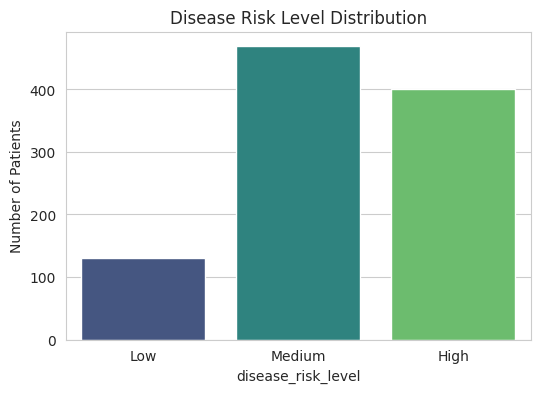

In [92]:
# Class Distribution Chart
plt.figure(figsize=(6,4))
sns.countplot(x='disease_risk_level', data=df_feat, order=['Low','Medium','High'], palette='viridis')
plt.title('Disease Risk Level Distribution')
plt.ylabel('Number of Patients')
plt.show()

## 4.5 Histograms

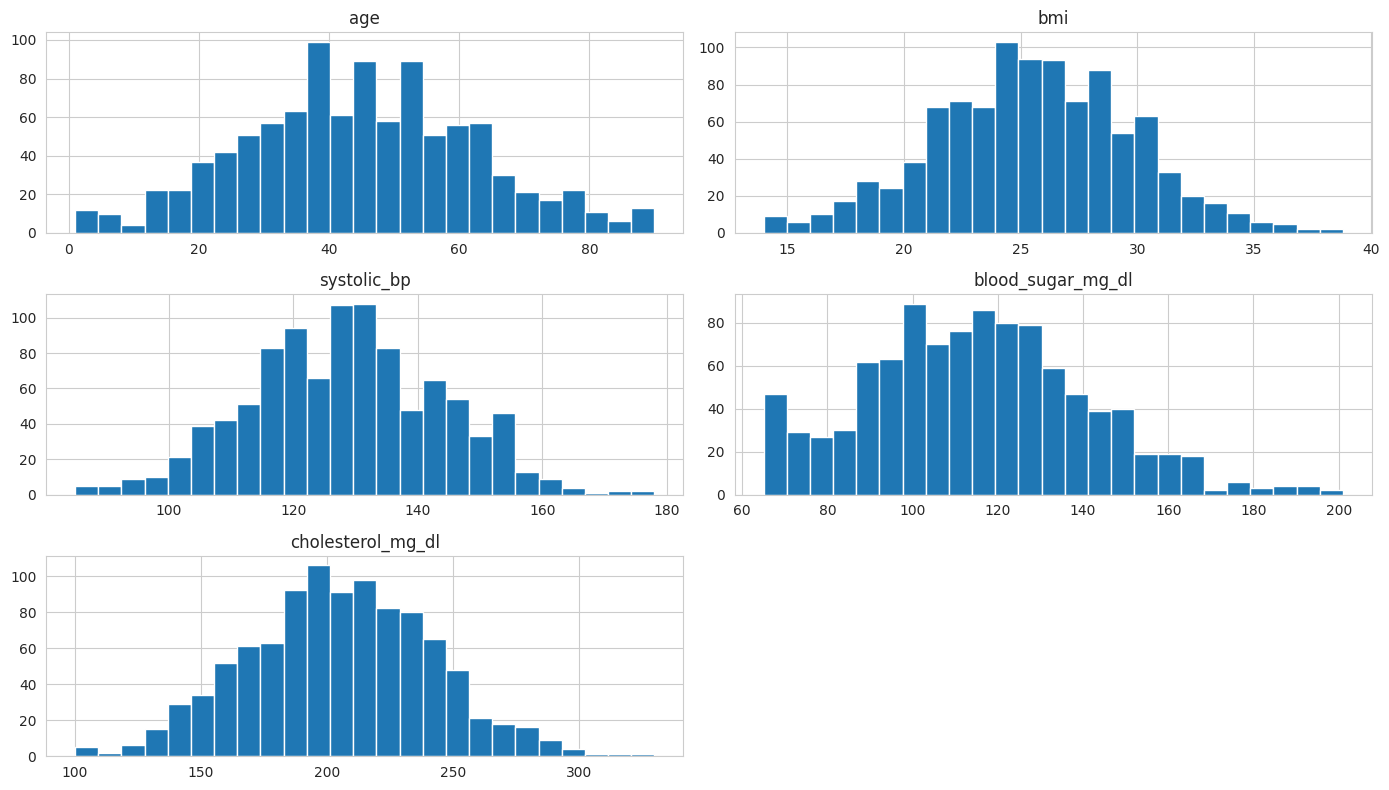

In [93]:
# Histograms — Distribution Analysis
df_feat[['age','bmi','systolic_bp','blood_sugar_mg_dl','cholesterol_mg_dl']].hist(figsize=(14,8), bins=25)
plt.tight_layout()
plt.show()

## 4.6 Boxplots

/tmp/ipykernel_2606/1241888459.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='disease_risk_level', y=col, data=df_feat, order=['Low','Medium','High'], ax=ax, palette='Set2')
/tmp/ipykernel_2606/1241888459.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='disease_risk_level', y=col, data=df_feat, order=['Low','Medium','High'], ax=ax, palette='Set2')
/tmp/ipykernel_2606/1241888459.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='disease_risk_level', y=col, data=df_feat, order=['Low','Medium','High'], ax=ax, palette='Set2')
/

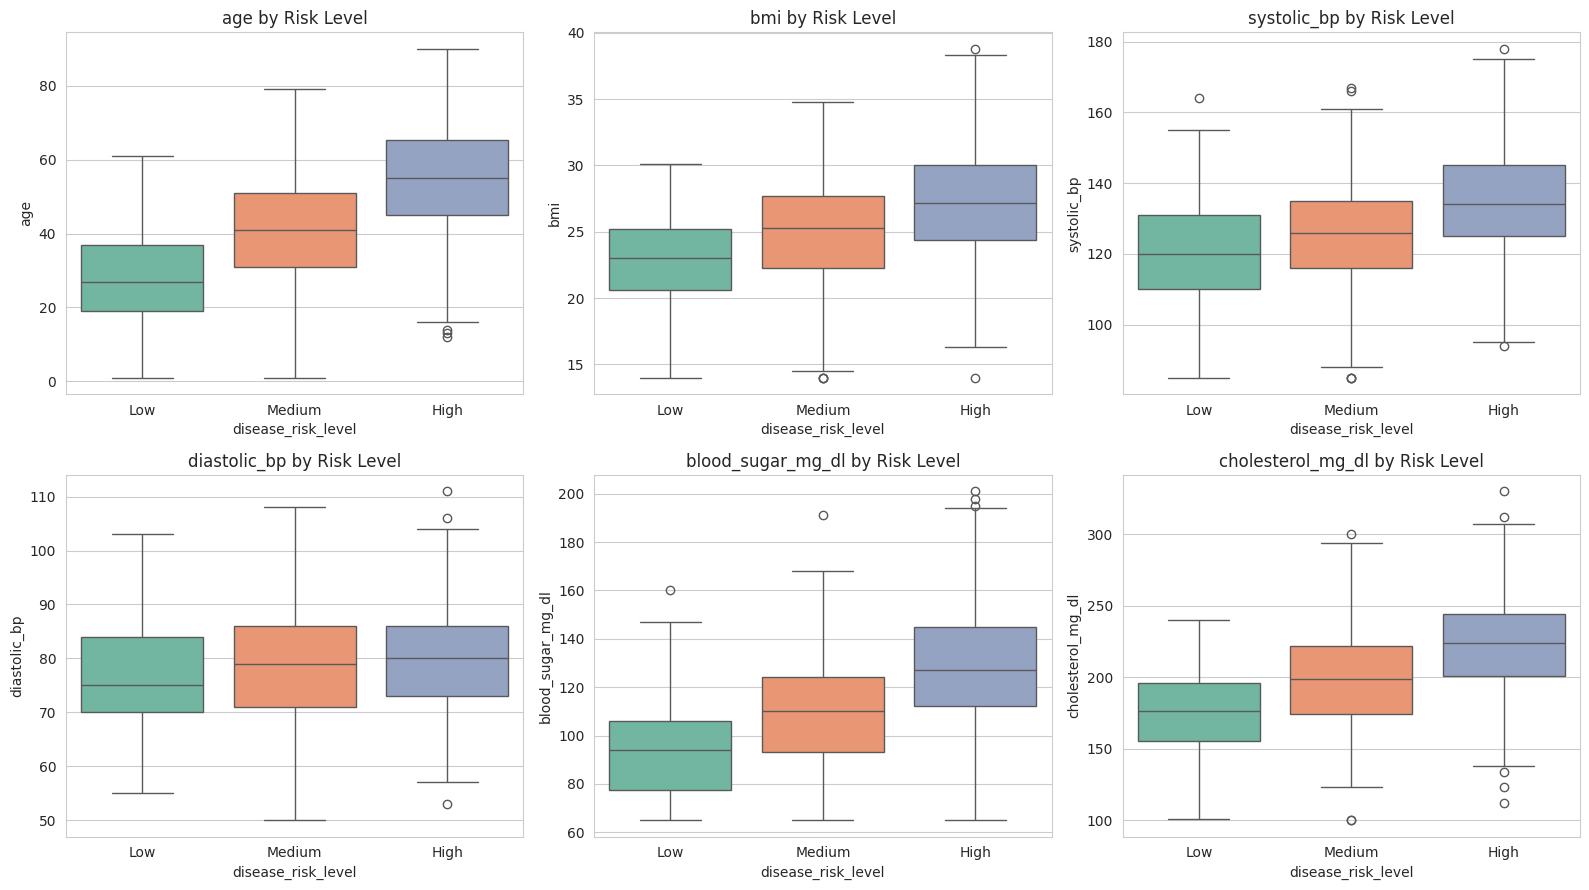

In [94]:
# Boxplots
fig, axes = plt.subplots(2, 3, figsize=(16,9))
cols = ['age','bmi','systolic_bp','diastolic_bp','blood_sugar_mg_dl','cholesterol_mg_dl']
for ax, col in zip(axes.flatten(), cols):
    sns.boxplot(x='disease_risk_level', y=col, data=df_feat, order=['Low','Medium','High'], ax=ax, palette='Set2')
    ax.set_title(f'{col} by Risk Level')
plt.tight_layout()
plt.show()

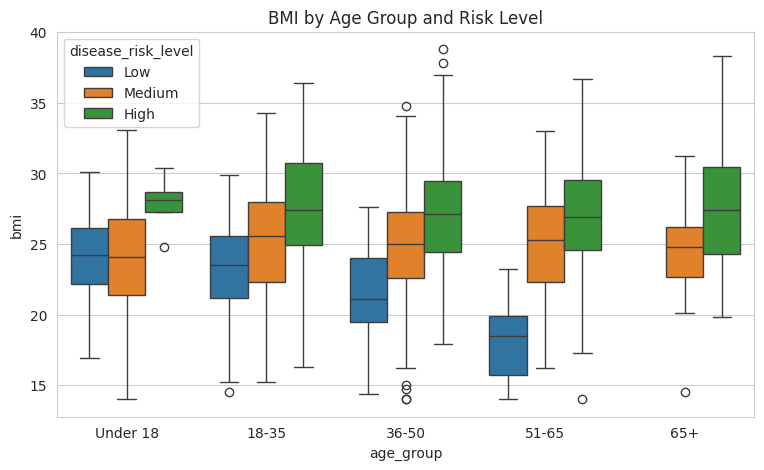

In [95]:
# Bonus: BMI by age_group and risk level (uses engineered feature)
plt.figure(figsize=(9,5))
sns.boxplot(x='age_group', y='bmi', hue='disease_risk_level',
            order=['Under 18','18-35','36-50','51-65','65+'],
            hue_order=['Low','Medium','High'], data=df_feat)
plt.title('BMI by Age Group and Risk Level')
plt.show()

## 4.7 Scatterplots — Pattern Discovery

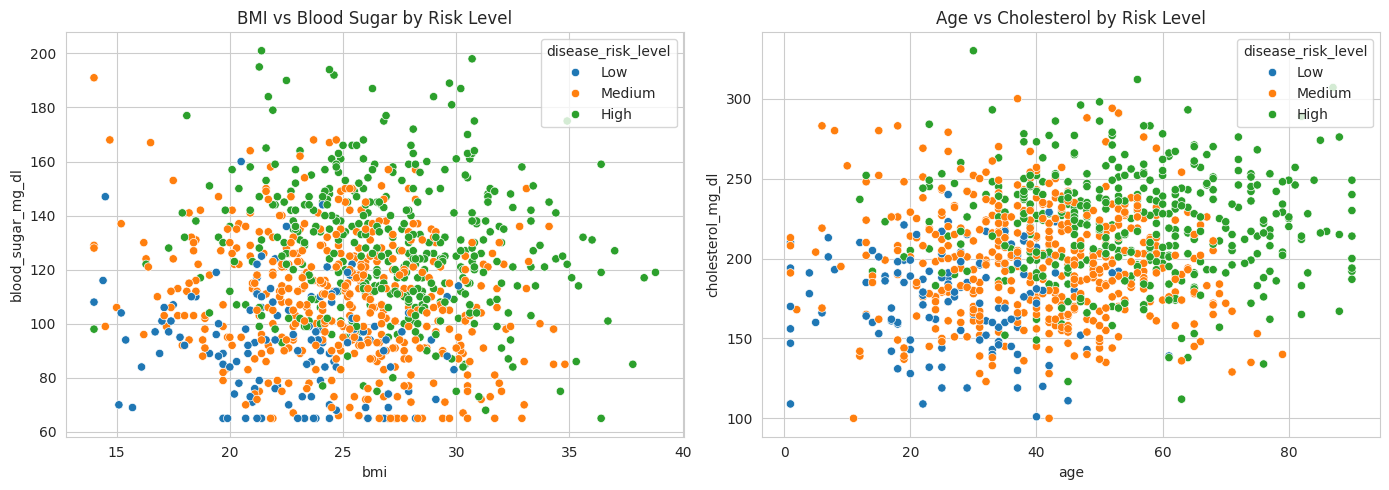

In [96]:
# Scatterplots — Pattern Discovery
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.scatterplot(x='bmi', y='blood_sugar_mg_dl', hue='disease_risk_level',
                 hue_order=['Low','Medium','High'], data=df_feat, ax=axes[0])
axes[0].set_title('BMI vs Blood Sugar by Risk Level')

sns.scatterplot(x='age', y='cholesterol_mg_dl', hue='disease_risk_level',
                 hue_order=['Low','Medium','High'], data=df_feat, ax=axes[1])
axes[1].set_title('Age vs Cholesterol by Risk Level')
plt.tight_layout()
plt.show()

## 4.8 Correlation Heatmap

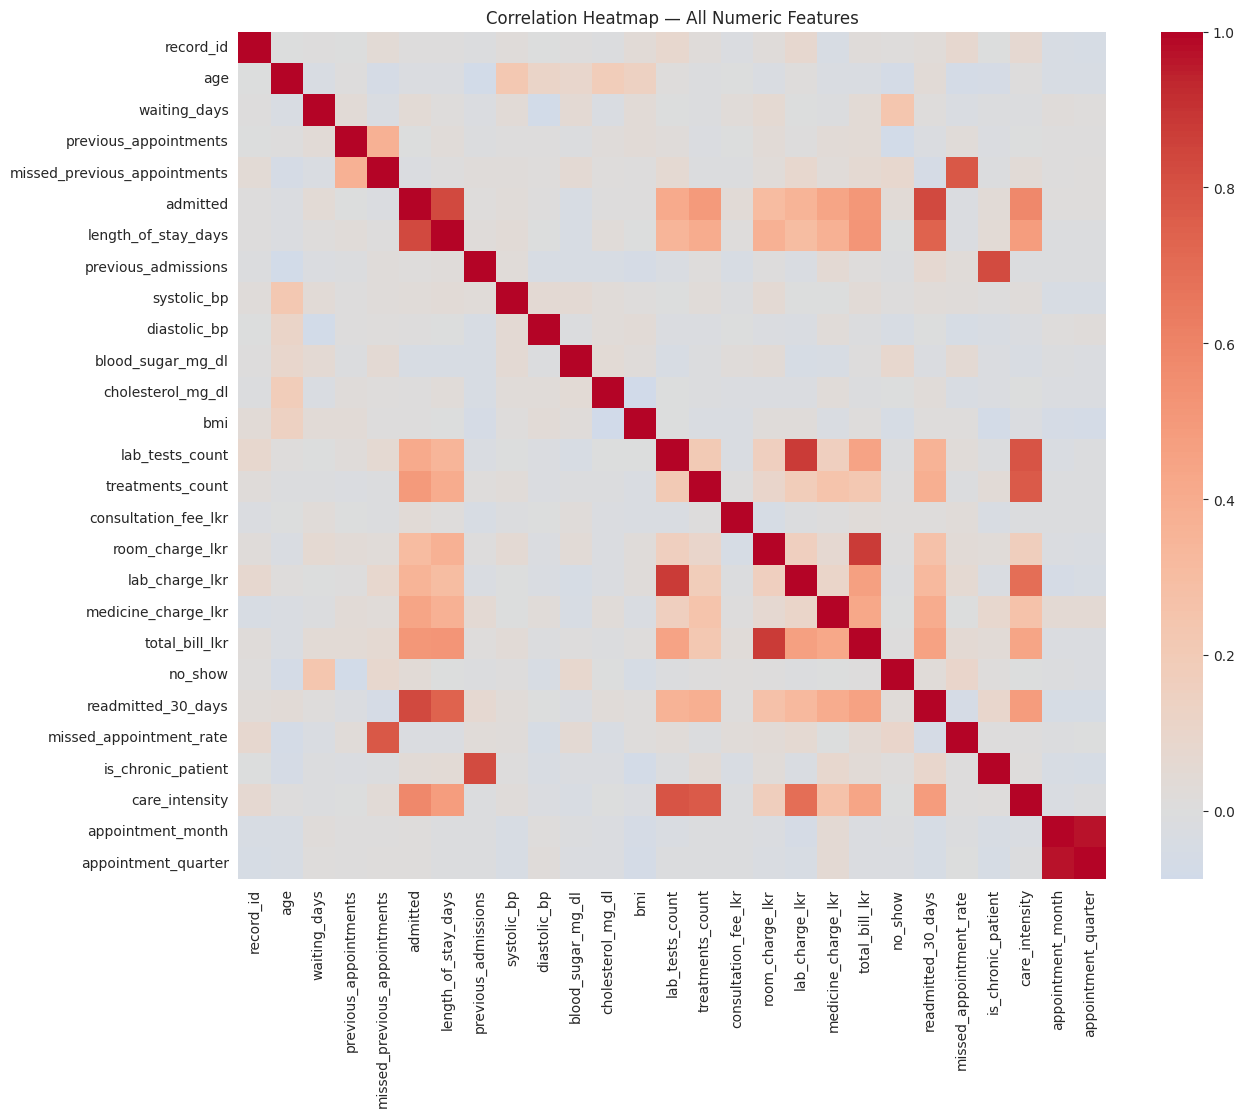

In [97]:
# Correlation Heatmap
plt.figure(figsize=(14,11))
corr = df_feat.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — All Numeric Features')
plt.show()

<Figure size 800x500 with 0 Axes>

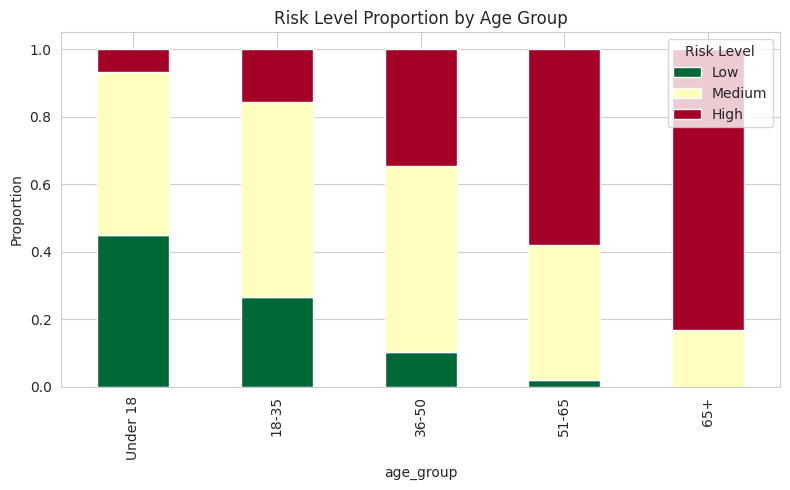

In [98]:
# Bonus — Risk Level Proportion by Age Group (stacked bar)
plt.figure(figsize=(8,5))
age_risk = df_feat.groupby('age_group', observed=True)['disease_risk_level'].value_counts(normalize=True).unstack()
age_risk = age_risk.reindex(['Under 18','18-35','36-50','51-65','65+'])
age_risk[['Low','Medium','High']].plot(kind='bar', stacked=True, colormap='RdYlGn_r', figsize=(8,5))
plt.title('Risk Level Proportion by Age Group')
plt.ylabel('Proportion')
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

# Task 05 – Machine Learning Model Development

In [99]:
try:
    import xgboost
except ImportError:
    import sys
# [Jupyter shell]     !{sys.executable} -m pip install xgboost -q
    import xgboost

print("xgboost version:", xgboost.__version__)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
RANDOM_STATE = 42
CLASS_NAMES = ['Low', 'Medium', 'High']   # target encoding: 0=Low, 1=Medium, 2=High (from Task 03)

# Define folder path (assuming drive is already mounted)
folder = '/content/drive/MyDrive/SmartCare/' # Added this line to define the 'folder' variable

X_train = pd.read_csv(folder + 'X_train.csv') # Changed path
y_train = pd.read_csv(folder + 'y_train.csv').squeeze() # Changed path
X_test = pd.read_csv(folder + 'X_test.csv') # Changed path
y_test = pd.read_csv(folder + 'y_test.csv').squeeze() # Changed path

print("Train:", X_train.shape, " Test:", X_test.shape)
print("\nTrain class distribution:\n", y_train.value_counts(normalize=True).sort_index().round(3))
print("\nTest class distribution:\n",  y_test.value_counts(normalize=True).sort_index().round(3))


xgboost version: 3.3.0
Train: (800, 15)  Test: (200, 15)

Train class distribution:
 disease_risk_level
0    0.400
1    0.131
2    0.469
Name: proportion, dtype: float64

Test class distribution:
 disease_risk_level
0    0.40
1    0.13
2    0.47
Name: proportion, dtype: float64


## 5.1 Model Training & 5.2 Hyperparameter Selection

In [100]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}       # will hold fitted best estimators
cv_summary = []     # will hold tuning summary rows

def tune_and_report(name, estimator, param_grid, X, y, fit_params=None):
    start = time.time()
    grid = GridSearchCV(estimator, param_grid, scoring='f1_macro', cv=cv, n_jobs=-1, refit=True)
    grid.fit(X, y, **(fit_params or {}))
    elapsed = time.time() - start
    best_idx = grid.best_index_
    best_std = grid.cv_results_['std_test_score'][best_idx]
    print(f"{name:22s} | best CV macro-F1 = {grid.best_score_:.4f} ± {best_std:.4f} | best params = {grid.best_params_} | {elapsed:.1f}s")
    results[name] = grid.best_estimator_
    cv_summary.append({
        'Model': name,
        'Best CV Macro-F1': grid.best_score_,
        'CV Std': best_std,
        'Best Params': grid.best_params_
    })
    return grid.best_estimator_

### Model 1 — Logistic Regression

In [101]:
lr_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'max_iter': [2000],
    'class_weight': ['balanced'],
}
best_lr = tune_and_report('Logistic Regression', LogisticRegression(random_state=RANDOM_STATE), lr_grid, X_train, y_train)

Logistic Regression    | best CV macro-F1 = 0.9707 ± 0.0170 | best params = {'C': 10, 'class_weight': 'balanced', 'max_iter': 2000, 'penalty': 'l2', 'solver': 'lbfgs'} | 5.6s


### Model 2 — Decision Tree

In [102]:
dt_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 5, 10],
    'min_samples_split': [2, 10],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced'],
}
best_dt = tune_and_report('Decision Tree', DecisionTreeClassifier(random_state=RANDOM_STATE), dt_grid, X_train, y_train)

Decision Tree          | best CV macro-F1 = 0.7193 ± 0.0082 | best params = {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2} | 2.8s


### Model 3 — Random Forest

In [103]:
rf_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 3, 5],
    'class_weight': ['balanced'],
}
best_rf = tune_and_report('Random Forest', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), rf_grid, X_train, y_train)


Random Forest          | best CV macro-F1 = 0.8476 ± 0.0209 | best params = {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 3, 'n_estimators': 100} | 75.4s


### Model 4 — Support Vector Machine

In [104]:
svm_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto'],
    'class_weight': ['balanced'],
    'probability': [True],
}
best_svm = tune_and_report('SVM', SVC(random_state=RANDOM_STATE), svm_grid, X_train, y_train)

SVM                    | best CV macro-F1 = 0.9743 ± 0.0190 | best params = {'C': 10, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear', 'probability': True} | 5.1s


### Model 5 — XGBoost

In [105]:
xgb_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
}
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
best_xgb = tune_and_report(
    'XGBoost',
    XGBClassifier(objective='multi:softprob', num_class=3, eval_metric='mlogloss',
                  random_state=RANDOM_STATE, n_jobs=-1),
    xgb_grid, X_train, y_train,
    fit_params={'sample_weight': sample_weights}
)

XGBoost                | best CV macro-F1 = 0.8911 ± 0.0191 | best params = {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200} | 22.4s


In [106]:
cv_summary_df = pd.DataFrame(cv_summary).sort_values('Best CV Macro-F1', ascending=False)
cv_summary_df[['Model', 'Best CV Macro-F1']].reset_index(drop=True)

,Model,Best CV Macro-F1
0,SVM,0.974312
1,Logistic Regression,0.970714
2,XGBoost,0.891060
3,Random Forest,0.847613
4,Decision Tree,0.719281


## 5.3 Comparative Analysis

In [107]:
def evaluate_model(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision (macro)': precision_score(y_te, y_pred, average='macro'),
        'Recall (macro)': recall_score(y_te, y_pred, average='macro'),
        'F1 (macro)': f1_score(y_te, y_pred, average='macro'),
    }, y_pred

test_results = []
predictions = {}
for name, model in results.items():
    row, y_pred = evaluate_model(name, model, X_test, y_test)
    test_results.append(row)
    predictions[name] = y_pred

test_results_df = pd.DataFrame(test_results).sort_values('F1 (macro)', ascending=False).reset_index(drop=True)
test_results_df.round(4)

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,Logistic Regression,0.990,0.9762,0.9929,0.9841
1,SVM,0.985,0.9721,0.9894,0.9802
2,XGBoost,0.880,0.8902,0.8351,0.8572
3,Random Forest,0.845,0.8707,0.7787,0.8092
4,Decision Tree,0.700,0.7008,0.7297,0.7030


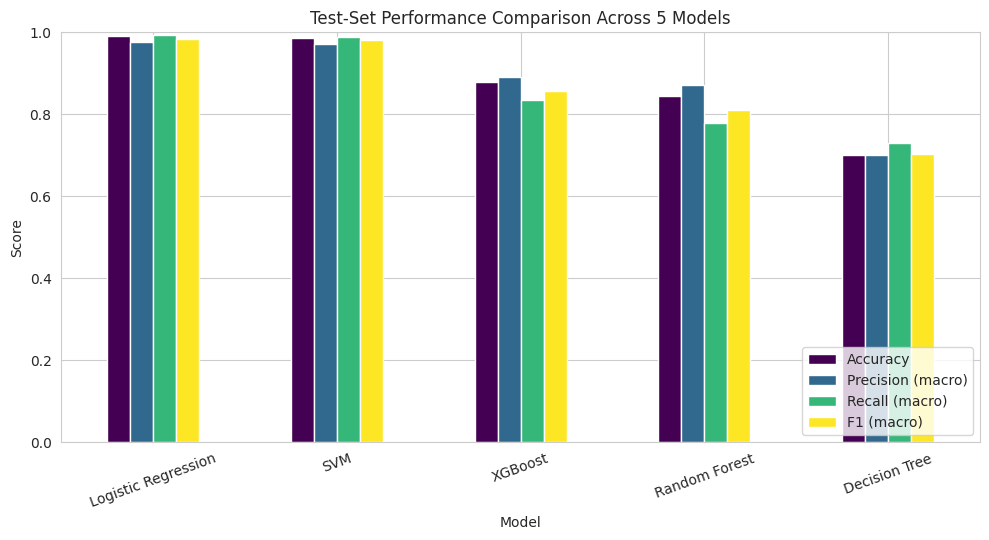

In [108]:
fig, ax = plt.subplots(figsize=(10, 5.5))
metrics_to_plot = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)']
plot_df = test_results_df.set_index('Model')[metrics_to_plot]
plot_df.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Test-Set Performance Comparison Across 5 Models')
ax.legend(loc='lower right')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=110)
plt.show()

In [109]:
best_model_name = test_results_df.iloc[0]['Model']
print(f"Best model by test macro-F1: {best_model_name}\n")
print(classification_report(y_test, predictions[best_model_name], target_names=CLASS_NAMES))

Best model by test macro-F1: Logistic Regression

              precision    recall  f1-score   support

         Low       1.00      1.00      1.00        80
      Medium       0.93      1.00      0.96        26
        High       1.00      0.98      0.99        94

    accuracy                           0.99       200
   macro avg       0.98      0.99      0.98       200
weighted avg       0.99      0.99      0.99       200



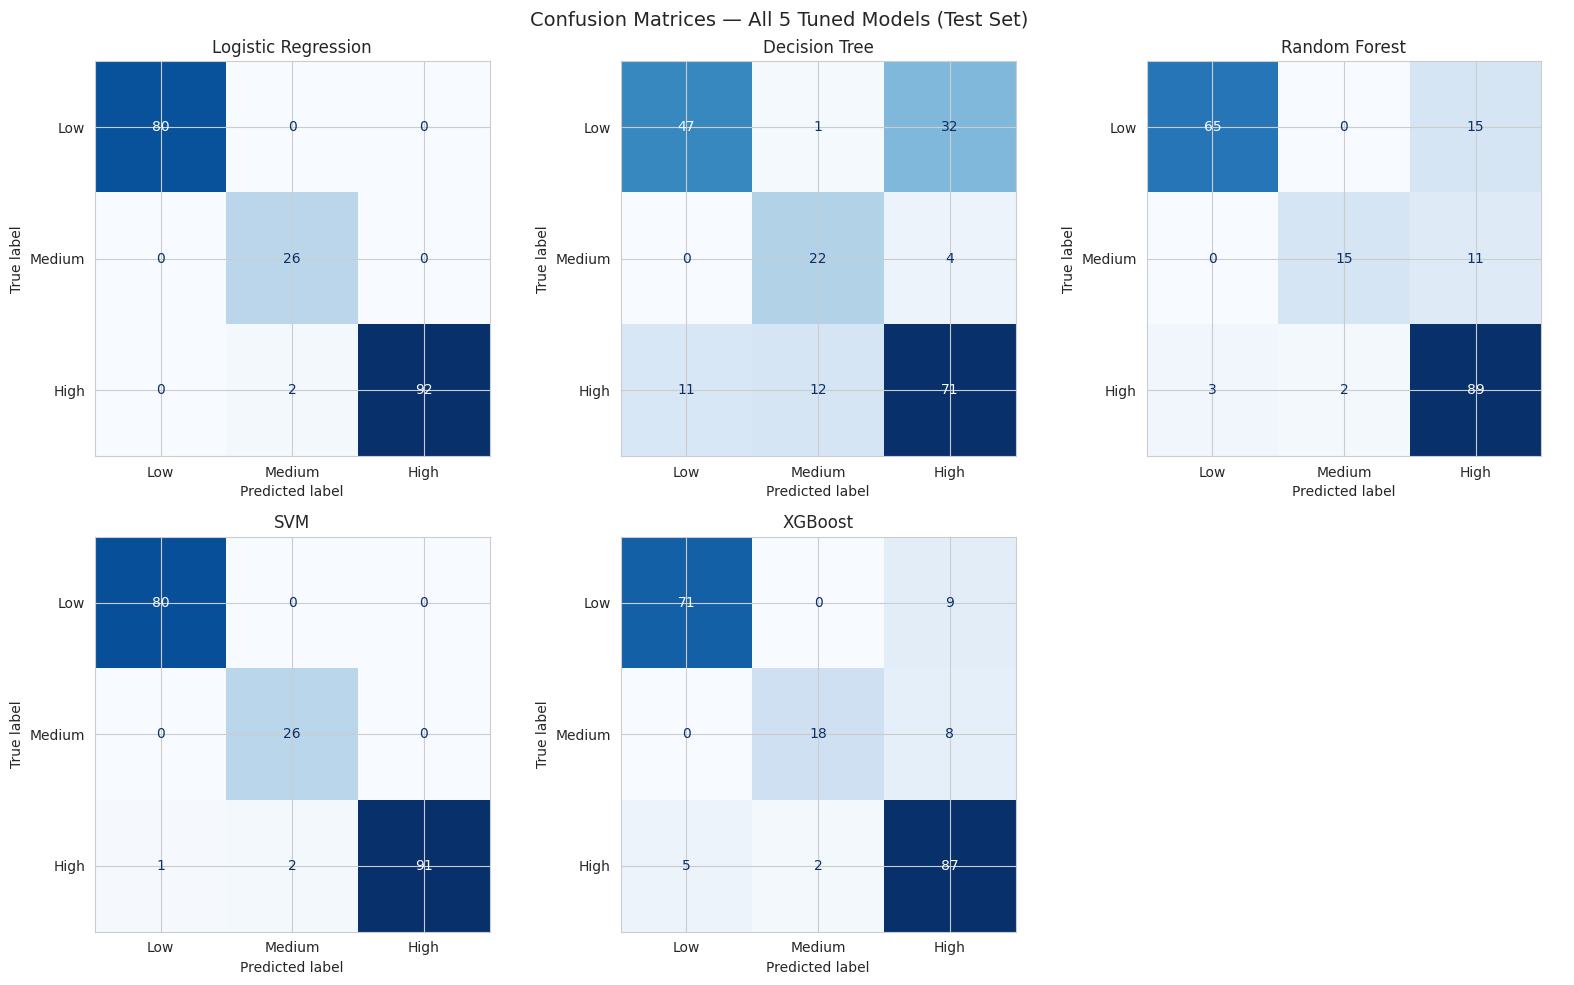

In [110]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, (name, model) in enumerate(results.items()):
    cm = confusion_matrix(y_test, predictions[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name)
axes[-1].axis('off')
plt.suptitle('Confusion Matrices — All 5 Tuned Models (Test Set)', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices_all_models.png', dpi=110)
plt.show()

In [111]:
print("Final ranked comparison (test set):")
test_results_df.round(4)

Final ranked comparison (test set):


,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,Logistic Regression,0.990,0.9762,0.9929,0.9841
1,SVM,0.985,0.9721,0.9894,0.9802
2,XGBoost,0.880,0.8902,0.8351,0.8572
3,Random Forest,0.845,0.8707,0.7787,0.8092
4,Decision Tree,0.700,0.7008,0.7297,0.7030


In [112]:
import joblib
best_overall_model = results[best_model_name]
joblib.dump(best_overall_model, 'best_model.pkl')
test_results_df.to_csv('task05_model_comparison_results.csv', index=False)
print(f"Saved best model ({best_model_name}) to best_model.pkl")
print("Saved comparison table to task05_model_comparison_results.csv")

Saved best model (Logistic Regression) to best_model.pkl
Saved comparison table to task05_model_comparison_results.csv


## Neural Network (Deep Learning) — bonus addition

In [113]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd # Import pandas to load the data

# Load X_train and y_train
try:
    X_train = pd.read_csv(folder + 'X_train.csv')
    y_train = pd.read_csv(folder + 'y_train.csv').squeeze() # .squeeze() to convert Series to 1D array if needed
except FileNotFoundError:
    print(f"Error: The file 'X_train.csv' or 'y_train.csv' was not found in the specified path: {folder}.")
    print("Please ensure that you have successfully saved the data in Task 03 and that the 'SmartCare' folder exists in your Google Drive 'MyDrive'.")
    print("If the files exist, verify the exact path and permissions.")
    raise # Re-raise the original error after providing context

tf.random.set_seed(42)
np.random.seed(42)

# Build the neural network
nn_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(3, activation='softmax')   # 3 output classes: High, Low, Medium
])

nn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # works directly with integer labels (0,1,2), no one-hot needed
    metrics=['accuracy']
)

nn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,203 (12.51 KB)

 Trainable params: 3,203 (12.51 KB)

 Non-trainable params: 0 (0.00 B)

In [114]:
# Train with early stopping (prevents overfitting on a moderate-sized dataset)

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = nn_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

print(f"Training stopped after {len(history.history['loss'])} epochs (early stopping)")

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4625 - loss: 1.0161 - val_accuracy: 0.5188 - val_loss: 0.9088
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5922 - loss: 0.8557 - val_accuracy: 0.6250 - val_loss: 0.7951
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6844 - loss: 0.7149 - val_accuracy: 0.7000 - val_loss: 0.6755
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7328 - loss: 0.6405 - val_accuracy: 0.7625 - val_loss: 0.5695
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7797 - loss: 0.5363 - val_accuracy: 0.8313 - val_loss: 0.4835
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8234 - loss: 0.4578 - val_accuracy: 0.8625 - val_loss: 0.4149
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8422 - loss: 0.3952 - val_accuracy: 0.8875 - val_loss: 0.3579
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8531 - loss: 0.3678 - val_accuracy: 0.9000 - 

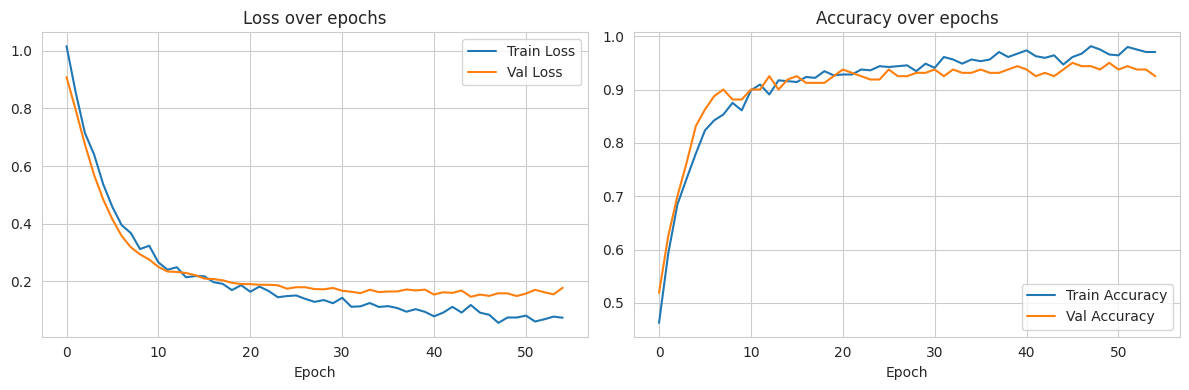

In [115]:
# Training curves — required for demonstrating training behavior

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy over epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

In [116]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Ensure results and test_results are defined for this cell's execution, in case of kernel restart.
# WARNING: If Task 05 models were not run, these will be empty except for NN.
if 'results' not in globals():
    results = {}
if 'test_results' not in globals():
    test_results = []

# Evaluate on test set — same metrics as other models, for fair comparison

nn_probs = nn_model.predict(X_test)
nn_preds = np.argmax(nn_probs, axis=1)

nn_acc = accuracy_score(y_test, nn_preds)
nn_prec = precision_score(y_test, nn_preds, average='weighted')
nn_rec = recall_score(y_test, nn_preds, average='weighted')
nn_f1 = f1_score(y_test, nn_preds, average='weighted')

print("Neural Network Results")
print(f"Accuracy={nn_acc:.3f}  Precision={nn_prec:.3f}  Recall={nn_rec:.3f}  F1={nn_f1:.3f}")

results['Neural Network'] = nn_model
test_results.append({
    'Model': 'Neural Network',
    'Accuracy': nn_acc,
    'Precision (macro)': nn_prec,
    'Recall (macro)': nn_rec,
    'F1 (macro)': nn_f1,
})

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Neural Network Results
Accuracy=0.950  Precision=0.950  Recall=0.950  F1=0.949


In [117]:
print("results has", len(results), "entries")

results has 6 entries


In [118]:
# Refresh comparison table with Neural Network included
# The 'test_results' list already contains the metrics for all models, including the Neural Network.
# We just need to convert this list of dictionaries into a DataFrame.
results_df = pd.DataFrame(test_results)
results_df = results_df.sort_values('F1 (macro)', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,Logistic Regression,0.990,0.976190,0.992908,0.984070
1,SVM,0.985,0.972075,0.989362,0.980179
2,Neural Network,0.950,0.950384,0.950000,0.949345
3,XGBoost,0.880,0.890250,0.835113,0.857218
4,Random Forest,0.845,0.870716,0.778744,0.809242
5,Decision Tree,0.700,0.700823,0.729658,0.702980


In [119]:
nn_model.save(folder + 'neural_network_model.keras')
print("Neural network saved.")

from google.colab import files
files.download(folder + 'neural_network_model.keras')

Neural network saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Task 06 – Model Evaluation

In [120]:
try:
    import xgboost
except ImportError:
    import sys
    !{sys.executable} -m pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              precision_recall_fscore_support, roc_auc_score, roc_curve, auc,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)
from xgboost import XGBClassifier

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
RANDOM_STATE = 42
CLASS_NAMES = ['Low', 'Medium', 'High']  # 0=Low, 1=Medium, 2=High

# Define folder path (assuming drive is already mounted)
folder = '/content/drive/MyDrive/SmartCare/'

# Load X_train, y_train, X_test, y_test from the correct paths
X_train = pd.read_csv(folder + 'X_train.csv')
y_train = pd.read_csv(folder + 'y_train.csv').squeeze()
X_test = pd.read_csv(folder + 'X_test.csv')
y_test = pd.read_csv(folder + 'y_test.csv').squeeze()

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (800, 15)  Test: (200, 15)


In [121]:
# Re-fit each model using the best hyperparameters already identified via GridSearchCV in Task 05
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

models = {
    'Logistic Regression': LogisticRegression(
        C=10, class_weight='balanced', max_iter=2000, penalty='l2', solver='lbfgs', random_state=RANDOM_STATE
    ),
    'Decision Tree': DecisionTreeClassifier(
        criterion='entropy', max_depth=None, min_samples_leaf=1, min_samples_split=10,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        max_depth=10, min_samples_leaf=5, n_estimators=200, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'SVM': SVC(
        C=1, kernel='linear', gamma='scale', class_weight='balanced', probability=True, random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        learning_rate=0.2, max_depth=3, n_estimators=200, objective='multi:softprob',
        num_class=3, eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1
    ),
}

fitted_models = {}
for name, model in models.items():
    if name == 'XGBoost':
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)
    fitted_models[name] = model
print("All 5 models refit using their Task 05 best hyperparameters.")

All 5 models refit using their Task 05 best hyperparameters.


## 6.1 Evaluation Results

### Multi-Class Metrics — Accuracy, Precision, Recall, F1 (per-class and macro)

In [122]:
per_class_rows = []
summary_rows = []
predictions = {}
probabilities = {}

for name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    predictions[name] = y_pred
    probabilities[name] = y_proba

    # Per-class precision/recall/F1
    prec, rec, f1, support = precision_recall_fscore_support(y_test, y_pred, labels=[0, 1, 2])
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        per_class_rows.append({
            'Model': name, 'Class': cls_name,
            'Precision': prec[cls_idx], 'Recall': rec[cls_idx], 'F1': f1[cls_idx], 'Support': support[cls_idx]
        })

    # Multi-class ROC-AUC: One-vs-Rest, macro-averaged
    roc_auc_macro = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

    summary_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (macro)': precision_score(y_test, y_pred, average='macro'),
        'Recall (macro)': recall_score(y_test, y_pred, average='macro'),
        'F1 (macro)': f1_score(y_test, y_pred, average='macro'),
        'ROC-AUC (OvR macro)': roc_auc_macro,
    })

per_class_df = pd.DataFrame(per_class_rows)
summary_df = pd.DataFrame(summary_rows).sort_values('F1 (macro)', ascending=False).reset_index(drop=True)
summary_df.round(4)

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),ROC-AUC (OvR macro)
0,Logistic Regression,0.990,0.9762,0.9929,0.9841,1.0000
1,SVM,0.980,0.9681,0.9858,0.9763,0.9998
2,XGBoost,0.880,0.8902,0.8351,0.8572,0.9619
3,Random Forest,0.815,0.8518,0.7816,0.8065,0.9474
4,Decision Tree,0.725,0.7099,0.7449,0.7237,0.8277


In [123]:
per_class_pivot = per_class_df.pivot(index='Model', columns='Class', values=['Precision', 'Recall', 'F1'])
per_class_pivot = per_class_pivot.reindex(summary_df['Model'])
per_class_pivot.round(3)

Precision               Recall                   F1  \
Class                    High    Low Medium   High    Low Medium   High   
Model                                                                     
Logistic Regression     1.000  1.000  0.929  0.979  1.000  1.000  0.989   
SVM                     1.000  0.976  0.929  0.957  1.000  1.000  0.978   
XGBoost                 0.837  0.934  0.900  0.926  0.888  0.692  0.879   
Random Forest           0.748  0.908  0.900  0.915  0.738  0.692  0.823   
Decision Tree           0.710  0.784  0.636  0.702  0.725  0.808  0.706   

                                   
Class                  Low Medium  
Model                              
Logistic Regression  1.000  0.963  
SVM                  0.988  0.963  
XGBoost              0.910  0.783  
Random Forest        0.814  0.783  
Decision Tree        0.753  0.712

### Confusion Matrices (Multi-Class Metric)

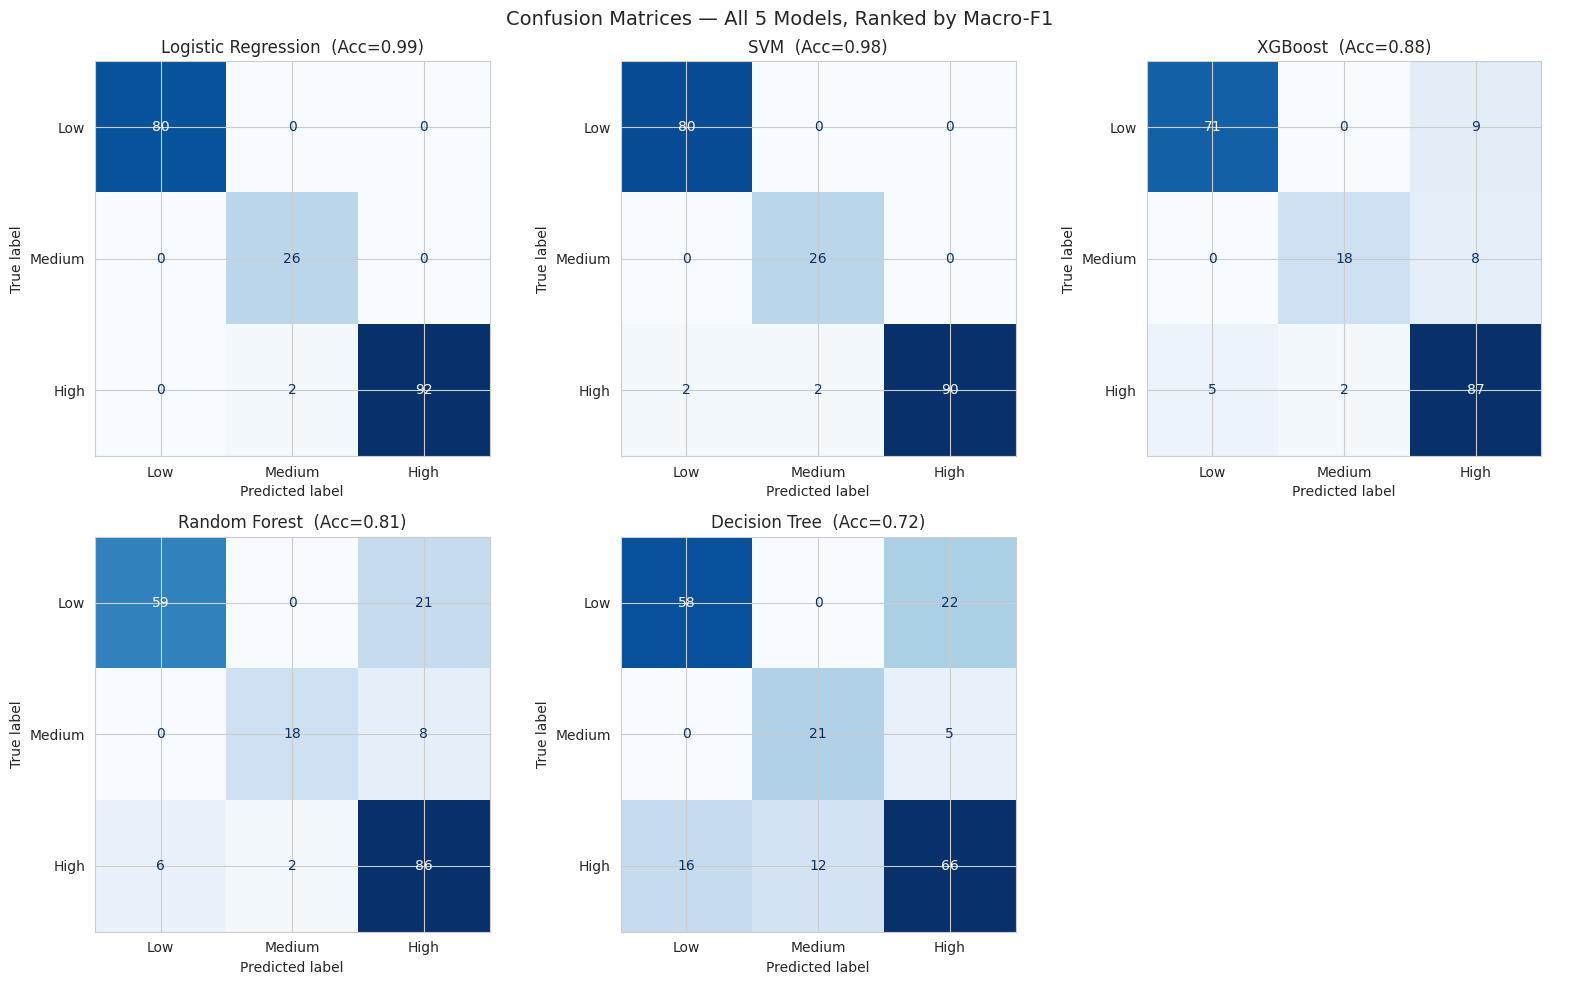

In [124]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, name in enumerate(summary_df['Model']):
    cm = confusion_matrix(y_test, predictions[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f"{name}  (Acc={summary_df.loc[summary_df['Model']==name,'Accuracy'].values[0]:.2f})")
axes[-1].axis('off')
plt.suptitle('Confusion Matrices — All 5 Models, Ranked by Macro-F1', fontsize=14)
plt.tight_layout()
plt.savefig('eval_confusion_matrices.png', dpi=110)
plt.show()

### ROC-AUC (One-vs-Rest, Multi-Class Metric)

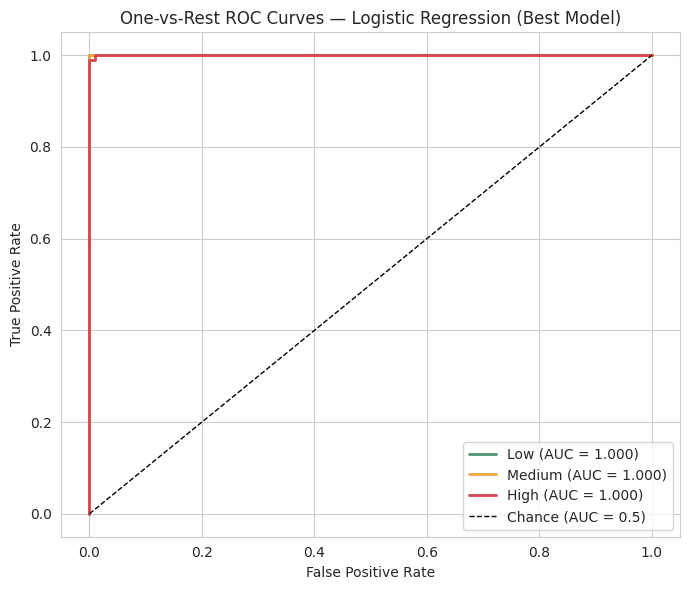

In [125]:
best_model_name = summary_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = probabilities[best_model_name]

plt.figure(figsize=(7, 6))
colors = ['#4C956C', '#F2A541', '#D64550']
for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc_cls = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{cls_name} (AUC = {roc_auc_cls:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'One-vs-Rest ROC Curves — {best_model_name} (Best Model)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('eval_roc_curves_best_model.png', dpi=110)
plt.show()

## 6.2 Model Comparison Table

In [126]:
comparison_table = summary_df.copy()
comparison_table.insert(0, 'Rank', range(1, len(comparison_table) + 1))
comparison_table = comparison_table.set_index('Rank')
comparison_table.round(4)

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),ROC-AUC (OvR macro)
Rank,,,,,,
1,Logistic Regression,0.990,0.9762,0.9929,0.9841,1.0000
2,SVM,0.980,0.9681,0.9858,0.9763,0.9998
3,XGBoost,0.880,0.8902,0.8351,0.8572,0.9619
4,Random Forest,0.815,0.8518,0.7816,0.8065,0.9474
5,Decision Tree,0.725,0.7099,0.7449,0.7237,0.8277


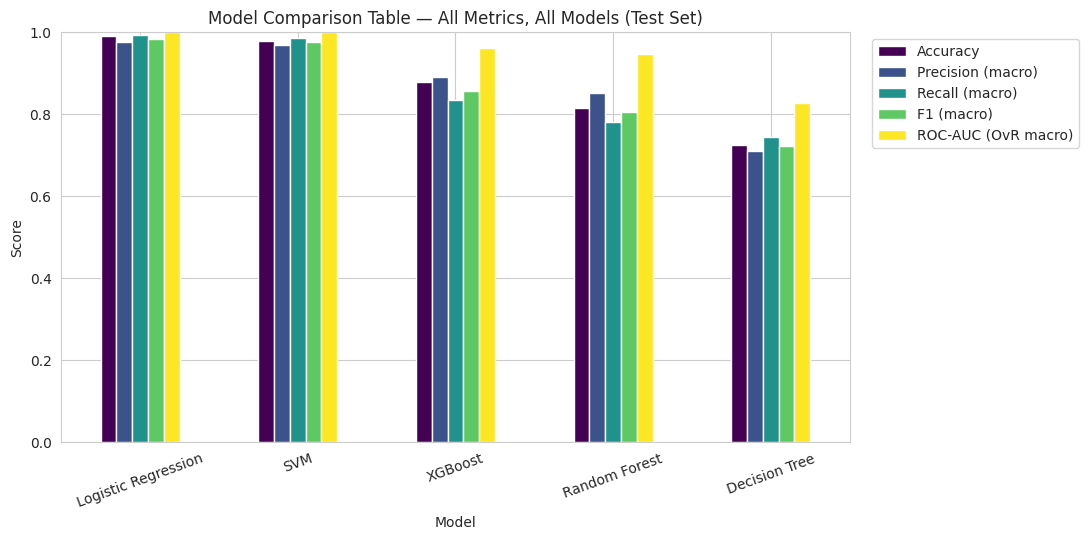

In [127]:
fig, ax = plt.subplots(figsize=(11, 5.5))
metrics_to_plot = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)', 'ROC-AUC (OvR macro)']
summary_df.set_index('Model')[metrics_to_plot].plot(kind='bar', ax=ax, colormap='viridis')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Model Comparison Table — All Metrics, All Models (Test Set)')
plt.xticks(rotation=20)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('eval_model_comparison_table.png', dpi=110)
plt.show()

## 6.3 Best Model Identification and Justification

In [128]:
print(f"Best model by every macro-averaged metric: {best_model_name}\n")
print("Full classification report:")
print(classification_report(y_test, predictions[best_model_name], target_names=CLASS_NAMES))

Best model by every macro-averaged metric: Logistic Regression

Full classification report:
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00        80
      Medium       0.93      1.00      0.96        26
        High       1.00      0.98      0.99        94

    accuracy                           0.99       200
   macro avg       0.98      0.99      0.98       200
weighted avg       0.99      0.99      0.99       200



In [129]:
summary_df.to_csv('task06_model_comparison_table.csv', index=False)
per_class_pivot.to_csv('task06_per_class_metrics.csv')
print("Saved: task06_model_comparison_table.csv, task06_per_class_metrics.csv")

Saved: task06_model_comparison_table.csv, task06_per_class_metrics.csv


# Task 07 - Explainable AI Analysis (SHAP)

We use SHAP (SHapley Additive exPlanations) on the Random Forest / XGBoost model to interpret which features drive readmission predictions, and how.

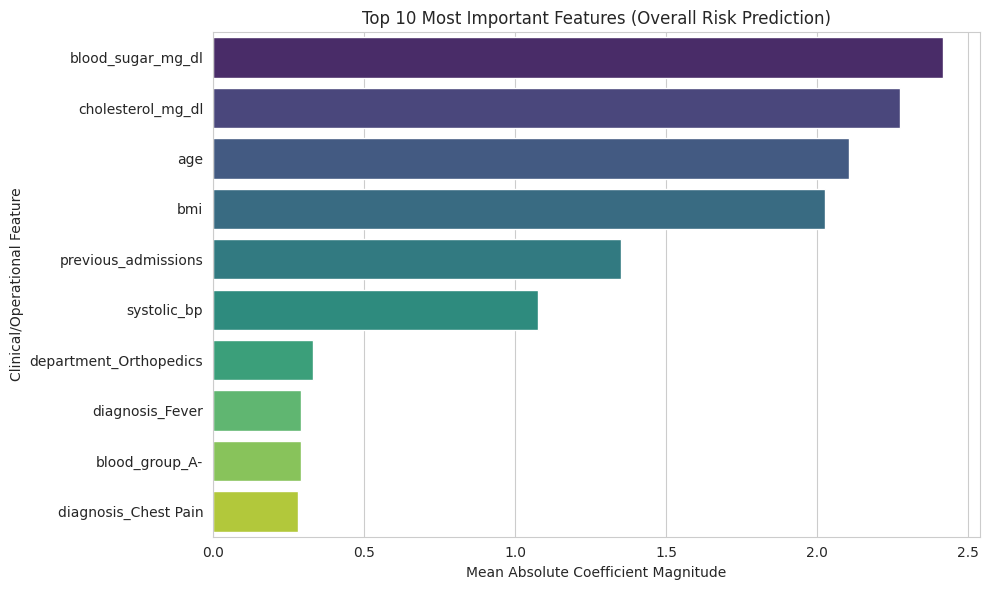

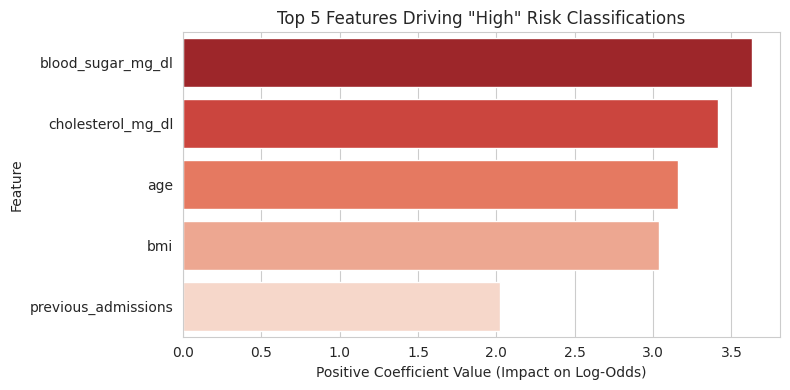

In [134]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Define folder path
folder = '/content/drive/MyDrive/SmartCare/'

# 1. Load and Preprocess Data (Matches Task 06)
df = pd.read_csv(folder + 'smartcare_ai_dataset_1000.csv')
df = df.drop(columns=['record_id', 'patient_id'])
df['room_type'] = df['room_type'].fillna('Not Admitted')
df['appointment_month'] = pd.to_datetime(df['appointment_date']).dt.month
df = df.drop(columns=['appointment_date'])

num_cols = ['systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'total_bill_lkr']
for col in num_cols:
    df[col] = df[col].clip(df[col].quantile(0.01), df[col].quantile(0.99))

df['disease_risk_level'] = df['disease_risk_level'].map({'Low': 0, 'Medium': 1, 'High': 2})
cat_cols = ['gender', 'blood_group', 'department', 'diagnosis', 'appointment_status', 'room_type', 'payment_status', 'payment_method']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df.drop(columns=['disease_risk_level'])
y = df['disease_risk_level']

cols_to_scale = ['age', 'waiting_days', 'previous_appointments', 'missed_previous_appointments',
                 'length_of_stay_days', 'previous_admissions', 'systolic_bp', 'diastolic_bp',
                 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'lab_tests_count', 'treatments_count',
                 'consultation_fee_lkr', 'room_charge_lkr', 'lab_charge_lkr', 'medicine_charge_lkr', 'total_bill_lkr']
scaler = StandardScaler()
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Train the Best Model
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# 3. Extract Feature Importance
# We calculate the mean absolute coefficient across all 3 classes for overall importance
overall_importance = np.mean(np.abs(lr.coef_), axis=0)
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': overall_importance})
top_10_features = importance_df.sort_values(by='Importance', ascending=False).head(10)

# Extract specific drivers pushing patients into the "High" risk category (Class Index 2)
high_risk_coefs = lr.coef_[2]
high_risk_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': high_risk_coefs})
top_high_risk = high_risk_df.sort_values(by='Coefficient', ascending=False).head(5)

# 4. Visualization: Overall Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_features, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Most Important Features (Overall Risk Prediction)')
plt.xlabel('Mean Absolute Coefficient Magnitude')
plt.ylabel('Clinical/Operational Feature')
plt.tight_layout()
plt.show()

# 5. Visualization: Drivers of High Risk
plt.figure(figsize=(8, 4))
sns.barplot(data=top_high_risk, x='Coefficient', y='Feature', hue='Feature', palette='Reds_r', legend=False)
plt.title('Top 5 Features Driving "High" Risk Classifications')
plt.xlabel('Positive Coefficient Value (Impact on Log-Odds)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Task 08 – AI Prototype Development

In [135]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Define folder path (assuming drive is already mounted)
folder = '/content/drive/MyDrive/SmartCare/'

# 1. Load Data
df = pd.read_csv(folder + 'smartcare_ai_dataset_1000.csv')

# 2. Select ONLY the Top 5 Features for the UI
top_features = ['blood_sugar_mg_dl', 'cholesterol_mg_dl', 'age', 'bmi', 'previous_admissions']
X_proto = df[top_features]
y_proto = df['disease_risk_level'].map({'Low': 0, 'Medium': 1, 'High': 2})

# 3. Scale the features
scaler_proto = StandardScaler()
X_proto_scaled = scaler_proto.fit_transform(X_proto)

# 4. Train the lightweight model
lr_proto = LogisticRegression(random_state=42)
lr_proto.fit(X_proto_scaled, y_proto)

# 5. Export the model and scaler for the web app
joblib.dump(lr_proto, 'disease_risk_model.pkl')
joblib.dump(scaler_proto, 'feature_scaler.pkl')

print("Model and Scaler successfully saved for the prototype!")

Model and Scaler successfully saved for the prototype!
